In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import re

In [3]:
times = []
errors = []

try:
    with open('../build/energy_log.txt', 'r') as file:
        for line in file:
            # Extract the numbers from lines like: "   Time:  1.72, solution L2 error: 1.6913e-07"
            match = re.search(r'Time:\s*([-\d.]+),\s*solution L2 error:\s*([-\d.eE+]+)', line)
            if match:
                times.append(float(match.group(1)))
                errors.append(float(match.group(2)))
    
    # Save parsed data to a CSV for transparency
    df_energy = pd.DataFrame({'Time': times, 'L2_Error': errors})
    df_energy.to_csv('parsed_energy_data.csv', index=False)
    print("Log parsed successfully! Found", len(times), "data points.")

except FileNotFoundError:
    print("Error: energy_log.txt not found. Run the C++ code and pipe the output to this file.")

Log parsed successfully! Found 15 data points.


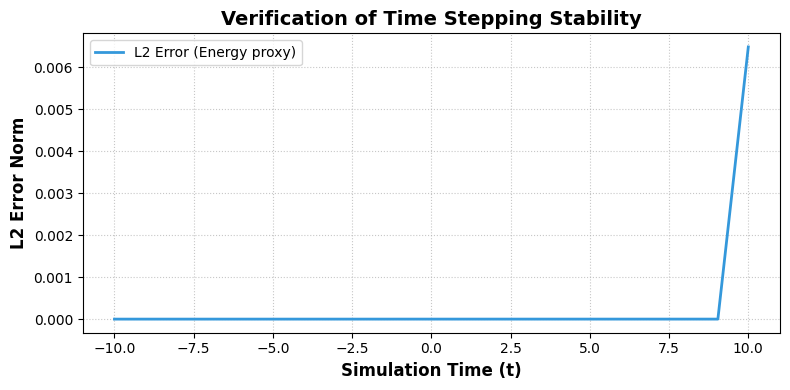

In [4]:
if times:
    plt.figure(figsize=(8, 4))
    plt.plot(times, errors, color='#3498db', linewidth=2, label='L2 Error (Energy proxy)')
    
    plt.xlabel('Simulation Time (t)', fontsize=12, fontweight='bold')
    plt.ylabel('L2 Error Norm', fontsize=12, fontweight='bold')
    plt.title('Verification of Time Stepping Stability', fontsize=14, fontweight='bold')
    
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig('energy_conservation.png', dpi=300)
    plt.show()